In [1]:
import pandas as pd
import numpy as np

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("cleaned_hotel_bookings.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74314 entries, 0 to 74313
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           74314 non-null  object 
 1   is_canceled                     74314 non-null  int64  
 2   lead_time                       74314 non-null  int64  
 3   arrival_date_year               74314 non-null  int64  
 4   arrival_date_month              74314 non-null  object 
 5   arrival_date_week_number        74314 non-null  int64  
 6   arrival_date_day_of_month       74313 non-null  float64
 7   stays_in_weekend_nights         74313 non-null  float64
 8   stays_in_week_nights            74313 non-null  float64
 9   adults                          74313 non-null  float64
 10  children                        74313 non-null  float64
 11  babies                          74313 non-null  float64
 12  meal                            

## Observation

The dataset information shows the number of records, columns, data types, and non-null values. This confirms that the dataset has been loaded correctly.

In [4]:
missing_values = df.isnull().sum()

print(missing_values)

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         1
stays_in_weekend_nights           1
stays_in_week_nights              1
adults                            1
children                          1
babies                            1
meal                              1
country                           1
market_segment                    1
distribution_channel              1
is_repeated_guest                 1
previous_cancellations            1
previous_bookings_not_canceled    1
reserved_room_type                1
assigned_room_type                1
booking_changes                   1
deposit_type                      1
agent                             1
days_in_waiting_list              1
customer_type                     1
adr                               1
required_car_parking_spaces 

## Observation

The missing value check confirms whether any columns still contain null values after preprocessing.

In [5]:
duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 6


## Observation

The dataset should contain zero duplicate records after preprocessing.

In [6]:
print(df.dtypes)

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month         float64
stays_in_weekend_nights           float64
stays_in_week_nights              float64
adults                            float64
children                          float64
babies                            float64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                 float64
previous_cancellations            float64
previous_bookings_not_canceled    float64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                   float64
deposit_type                       object
agent                             

## Observation

All numerical and categorical columns have appropriate data types for analysis and machine learning.

In [7]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,74314.000000,74314.000000,74314.000000,74314.000000,74313.000000,74313.000000,74313.00000,74313.000000,74313.000000,74313.000000,74313.000000,74313.000000,74313.000000,74313.000000,74313.000000,74313.000000,74313.000000,74313.000000,74313.000000
mean,0.323102,79.281414,2016.074037,28.132088,15.808957,1.028932,2.68599,1.870844,0.139114,0.011425,0.043761,0.035525,0.213166,0.265862,90.484074,0.862527,103.832401,0.092931,0.669614
std,0.467664,86.109015,0.653318,13.783619,8.833213,1.056305,2.13504,0.641367,0.457528,0.117576,0.204564,0.399803,1.874085,0.716694,113.739869,10.783967,56.250950,0.294388,0.815516
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,11.000000,2016.000000,17.000000,8.000000,0.000000,1.00000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000,68.000000,0.000000,0.000000
50%,0.000000,48.000000,2016.000000,29.000000,16.000000,1.000000,2.00000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000,95.000000,0.000000,0.000000
75%,1.000000,124.000000,2017.000000,39.000000,23.000000,2.000000,4.00000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,240.000000,0.000000,131.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.00000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,391.000000,5400.000000,8.000000,5.000000


## Observation

The statistical summary helps identify unusual values, such as extremely high or low prices or lead times.

In [8]:
print("Negative ADR values:", (df["adr"] < 0).sum())

print("Negative Lead Time values:", (df["lead_time"] < 0).sum())

print("Negative Adults values:", (df["adults"] < 0).sum())

Negative ADR values: 1
Negative Lead Time values: 0
Negative Adults values: 0


## Observation

No negative values should exist for ADR, lead time, or the number of adults.

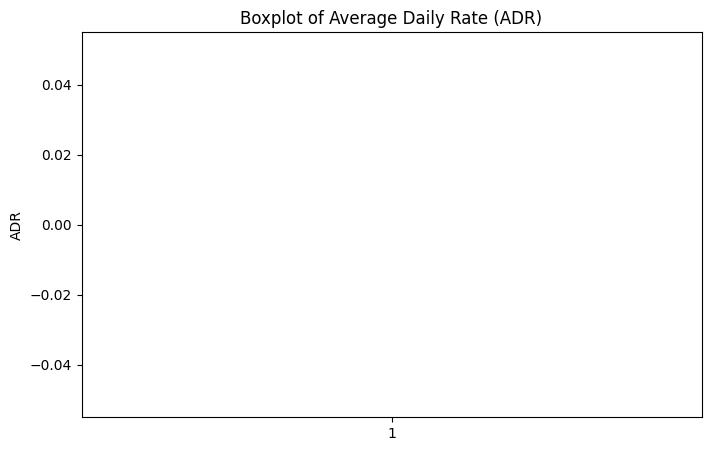

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.boxplot(df["adr"])

plt.title("Boxplot of Average Daily Rate (ADR)")

plt.ylabel("ADR")

plt.show()

## Observation

The boxplot helps identify unusually high or low room prices (outliers).

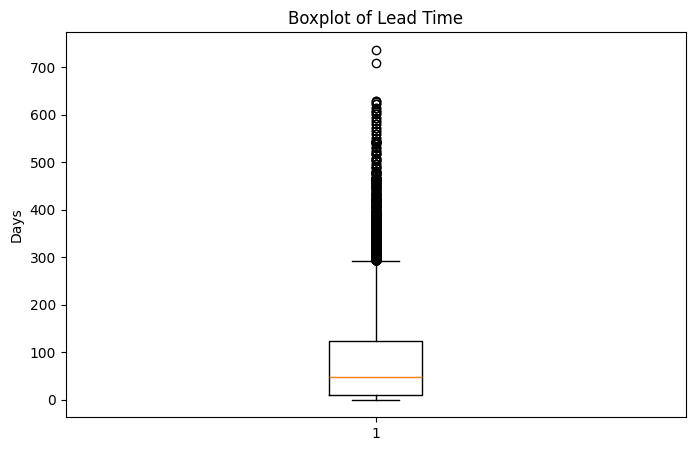

In [10]:
plt.figure(figsize=(8,5))

plt.boxplot(df["lead_time"])

plt.title("Boxplot of Lead Time")

plt.ylabel("Days")

plt.show()

## Observation

The boxplot highlights bookings made unusually far in advance.

In [11]:
print("Hotel Types:")
print(df["hotel"].unique())

print("\nCustomer Types:")
print(df["customer_type"].unique())

print("\nReservation Status:")
print(df["reservation_status"].unique())

Hotel Types:
['Resort Hotel' 'City Hotel']

Customer Types:
['Transient' 'Contract' 'Transient-Party' 'Group' nan]

Reservation Status:
['Check-Out' 'Canceled' 'No-Show' nan]


## Observation

The categorical values are consistent and contain only valid categories.

# Final Data Quality Validation Summary

The cleaned hotel booking dataset was successfully validated.

Validation Results:

- Dataset loaded successfully.
- Missing values handled.
- Duplicate records removed.
- Data types verified.
- Numerical statistics reviewed.
- No invalid negative values detected.
- Outliers identified for further analysis.
- Categorical values verified.

The dataset is suitable for demand analysis and Reinforcement Learning-based dynamic pricing.